In [19]:
import pandas as pd
import numpy as np

df_all = pd.read_csv(
    "../data/processed/multi_assets_supervised.csv",
    index_col=0,
    parse_dates=True
)

df_all.head()

,Close,High,Low,Open,Volume,Return,Target_Return,Target_Class,Ticker,Return_lag1,...,Momentum_5,Momentum_10,MA_5,MA_20,MA_ratio,Volatility_10,Volatility_30,Momentum_vol_adjusted,Price_vs_MA20,RSI
Date,,,,,,,,,,,,,,,,,,,,,
2015-08-03,26.446150,27.368326,26.240724,27.129408,279904000,-0.023578,-0.032083,0,AAPL,-0.008744,...,-0.035269,-0.103203,27.173177,27.874969,0.974824,0.013527,0.014586,-7.629384,0.948742,33.176882
2015-08-04,25.597666,26.280925,25.287296,26.218404,496554400,-0.032083,0.006629,1,AAPL,-0.023578,...,-0.070838,-0.123212,26.782871,27.751603,0.965093,0.015102,0.015439,-8.158675,0.922385,24.518907
2015-08-05,25.767363,26.222869,25.030514,25.220308,397250400,0.006629,0.002176,1,AAPL,-0.032083,...,-0.061712,-0.078422,26.443921,27.671554,0.955636,0.012185,0.015546,-6.435791,0.931186,21.462811
2015-08-06,25.823437,26.130726,25.596897,26.011848,211612000,0.002176,0.003388,1,AAPL,0.006629,...,-0.054906,-0.075973,26.143875,27.622221,0.946480,0.012396,0.015426,-6.128824,0.934879,18.412300
2015-08-07,25.910917,26.074656,25.682134,25.700078,154681600,0.003388,0.036357,1,AAPL,0.002176,...,-0.043340,-0.067928,25.909106,27.541424,0.940732,0.012885,0.015471,-5.271819,0.940798,10.037951


In [20]:
threshold = 0.002  # 0.2%

df_all["Target_Class"] = np.where(
    df_all.groupby("Ticker")["Return"].shift(-1) > threshold, 1,
    np.where(df_all.groupby("Ticker")["Return"].shift(-1) < -threshold, 0, np.nan)
)

In [21]:
df_all = df_all.dropna(subset=["Target_Class"])

In [22]:
df_all = df_all.sort_values(["Ticker", "Date"])


# RETURN LAGS
df_all["Return_lag1"] = df_all.groupby("Ticker")["Return"].shift(1)
df_all["Return_lag2"] = df_all.groupby("Ticker")["Return"].shift(2)
df_all["Return_lag3"] = df_all.groupby("Ticker")["Return"].shift(3)

df_all["Return_mean_5"] = df_all.groupby("Ticker")["Return"].transform(
    lambda x: x.rolling(5).mean()
)

# MOMENTUM
df_all["Momentum_5"] = df_all.groupby("Ticker")["Close"].transform(lambda x: x / x.shift(5) - 1)
df_all["Momentum_10"] = df_all.groupby("Ticker")["Close"].transform(lambda x: x / x.shift(10) - 1)


# MOVING AVERAGE
df_all["MA_5"] = df_all.groupby("Ticker")["Close"].transform(lambda x: x.rolling(5).mean())
df_all["MA_20"] = df_all.groupby("Ticker")["Close"].transform(lambda x: x.rolling(20).mean())

df_all["MA_ratio"] = df_all["MA_5"] / df_all["MA_20"]


# VOLATILITÀ
df_all["Volatility_10"] = df_all.groupby("Ticker")["Return"].transform(lambda x: x.rolling(10).std())
df_all["Volatility_30"] = df_all.groupby("Ticker")["Return"].transform(lambda x: x.rolling(30).std())

df_all["Momentum_vol_adjusted"] = df_all["Momentum_10"] / (df_all["Volatility_10"] + 1e-6)

df_all["Price_vs_MA20"] = df_all["Close"] / df_all["MA_20"]

delta = df_all.groupby("Ticker")["Close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.groupby(df_all["Ticker"]).transform(lambda x: x.rolling(14).mean())
avg_loss = loss.groupby(df_all["Ticker"]).transform(lambda x: x.rolling(14).mean())

rs = avg_gain / avg_loss

df_all["RSI"] = 100 - (100 / (1 + rs))

# TARGET REGRESSION (5 giorni avanti)
df_all["Target"] = df_all["Close"].shift(-5) / df_all["Close"] - 1

In [23]:
df_all = df_all.dropna()

In [24]:
df_all["Target_Class"].value_counts(normalize=True)

Target_Class
1.0    0.540372
0.0    0.459628
Name: proportion, dtype: float64

In [25]:
df_all.to_csv("../data/processed/multi_assets_threshold_002.csv")

In [26]:
threshold = 0.001  # 0.1%

df_all["Target_Class"] = np.where(
    df_all.groupby("Ticker")["Return"].shift(-1) > threshold, 1,
    np.where(df_all.groupby("Ticker")["Return"].shift(-1) < -threshold, 0, np.nan)
)

In [27]:
df_all = df_all.dropna(subset=["Target_Class"])

In [28]:
df_all = df_all.sort_values(["Ticker", "Date"])


# RETURN LAGS
df_all["Return_lag1"] = df_all.groupby("Ticker")["Return"].shift(1)
df_all["Return_lag2"] = df_all.groupby("Ticker")["Return"].shift(2)
df_all["Return_lag3"] = df_all.groupby("Ticker")["Return"].shift(3)

df_all["Return_mean_5"] = df_all.groupby("Ticker")["Return"].transform(
    lambda x: x.rolling(5).mean()
)

# MOMENTUM
df_all["Momentum_5"] = df_all.groupby("Ticker")["Close"].transform(lambda x: x / x.shift(5) - 1)
df_all["Momentum_10"] = df_all.groupby("Ticker")["Close"].transform(lambda x: x / x.shift(10) - 1)


# MOVING AVERAGE
df_all["MA_5"] = df_all.groupby("Ticker")["Close"].transform(lambda x: x.rolling(5).mean())
df_all["MA_20"] = df_all.groupby("Ticker")["Close"].transform(lambda x: x.rolling(20).mean())

df_all["MA_ratio"] = df_all["MA_5"] / df_all["MA_20"]


# VOLATILITÀ
df_all["Volatility_10"] = df_all.groupby("Ticker")["Return"].transform(lambda x: x.rolling(10).std())
df_all["Volatility_30"] = df_all.groupby("Ticker")["Return"].transform(lambda x: x.rolling(30).std())

df_all["Momentum_vol_adjusted"] = df_all["Momentum_10"] / (df_all["Volatility_10"] + 1e-6)

df_all["Price_vs_MA20"] = df_all["Close"] / df_all["MA_20"]

delta = df_all.groupby("Ticker")["Close"].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.groupby(df_all["Ticker"]).transform(lambda x: x.rolling(14).mean())
avg_loss = loss.groupby(df_all["Ticker"]).transform(lambda x: x.rolling(14).mean())

rs = avg_gain / avg_loss

df_all["RSI"] = 100 - (100 / (1 + rs))

# TARGET REGRESSION (5 giorni avanti)
df_all["Target"] = df_all["Close"].shift(-5) / df_all["Close"] - 1

In [29]:
df_all = df_all.dropna()

In [31]:
df_all.to_csv("../data/processed/multi_assets_threshold_001.csv")

<Figure size 1200x500 with 0 Axes>

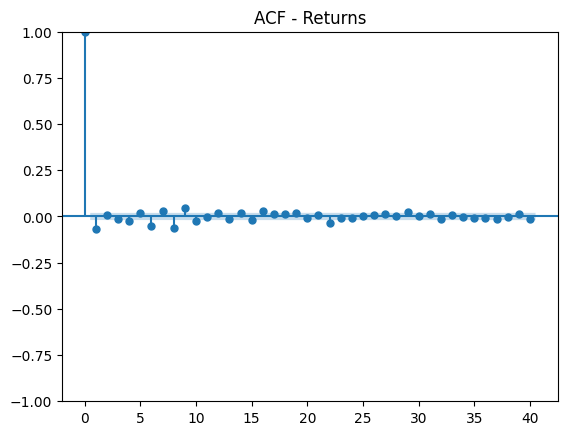

<Figure size 1200x500 with 0 Axes>

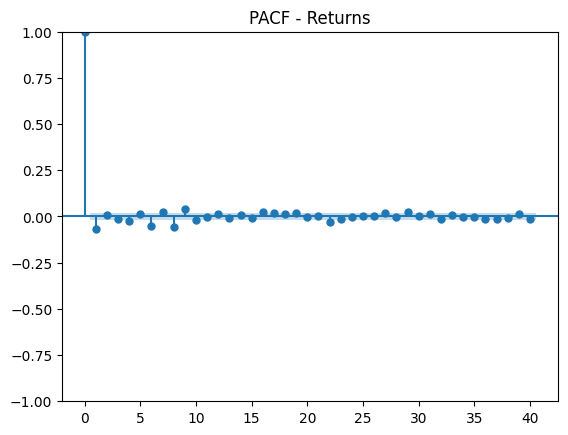

In [32]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# prendiamo i ritorni (molto meglio del prezzo)
returns = df_all["Return"].dropna()

plt.figure(figsize=(12,5))
plot_acf(returns, lags=40)
plt.title("ACF - Returns")
plt.show()

plt.figure(figsize=(12,5))
plot_pacf(returns, lags=40)
plt.title("PACF - Returns")
plt.show()

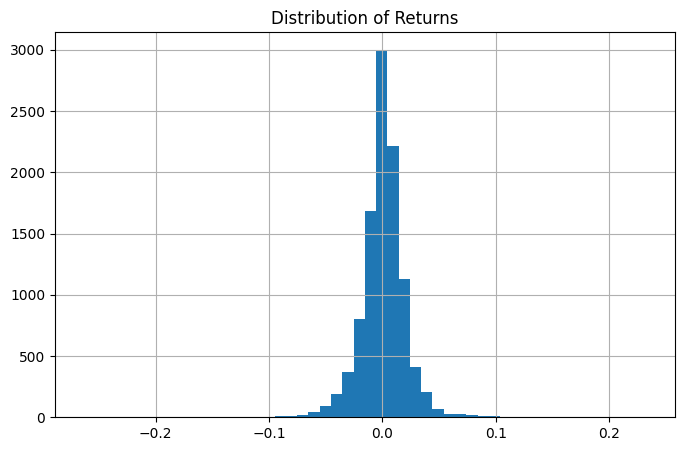

In [33]:
df_all["Return"].hist(bins=50, figsize=(8,5))
plt.title("Distribution of Returns")
plt.show()

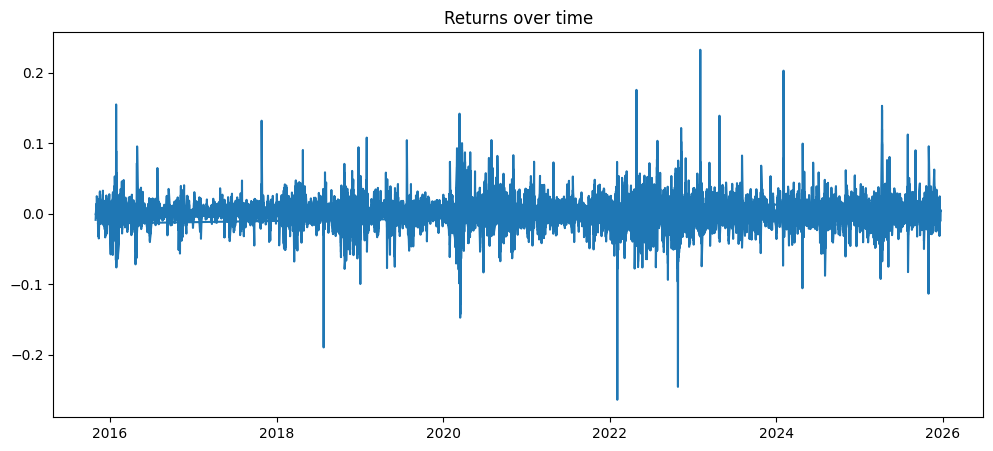

In [35]:
plt.figure(figsize=(12,5))
plt.plot(df_all["Return"])
plt.title("Returns over time")
plt.show()

In [37]:
print("Distribuzione Target_Class:")
print(df_all["Target_Class"].value_counts(normalize=True))

Distribuzione Target_Class:
Target_Class
1.0    0.534693
0.0    0.465307
Name: proportion, dtype: float64
